In [1]:
# “When opening a file, start by running all cells.”
import pandas as pd
import numpy as np

In [2]:
df = pd.read_excel(r"E:\Bank Complaint Analysis\Consumer_Complaints.xlsx")
df.head()

,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?
0,4848023,Referral,2021-10-24,2021-10-27,NY,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,NaN,Company has responded to the consumer and the ...,Closed with explanation,Yes
1,3621464,Web,2020-04-24,2020-04-24,FL,"Money transfer, virtual currency, or money ser...",Refund anticipation check,Lost or stolen check,NaN,Company has responded to the consumer and the ...,Closed with monetary relief,Yes
2,5818349,Web,2022-07-27,2022-07-27,CA,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account information incorrect,Company has responded to the consumer and the ...,Closed with explanation,Yes
3,7233015,Referral,2023-07-10,2023-07-11,CA,Credit card or prepaid card,General-purpose prepaid card,Problem getting a card or closing an account,"Trouble getting, activating, or registering a ...",NaN,In progress,NaN
4,5820224,Referral,2022-07-27,2022-07-28,VA,Credit card or prepaid card,General-purpose credit card or charge card,Closing your account,Company closed your account,Company has responded to the consumer and the ...,Closed with explanation,Yes


In [3]:
print(df.columns)

Index(['Complaint ID', 'Submitted via', 'Date submitted', 'Date received',
       'State', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Company public response', 'Company response to consumer',
       'Timely response?'],
      dtype='object')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62516 entries, 0 to 62515
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Complaint ID                  62516 non-null  int64         
 1   Submitted via                 62516 non-null  object        
 2   Date submitted                62516 non-null  datetime64[ns]
 3   Date received                 62516 non-null  datetime64[ns]
 4   State                         62516 non-null  object        
 5   Product                       62516 non-null  object        
 6   Sub-product                   62509 non-null  object        
 7   Issue                         62516 non-null  object        
 8   Sub-issue                     51658 non-null  object        
 9   Company public response       60341 non-null  object        
 10  Company response to consumer  62516 non-null  object        
 11  Timely response?            

In [5]:
df.isnull().sum()

Complaint ID                        0
Submitted via                       0
Date submitted                      0
Date received                       0
State                               0
Product                             0
Sub-product                         7
Issue                               0
Sub-issue                       10858
Company public response          2175
Company response to consumer        0
Timely response?                 1494
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df = df.dropna(subset=['Sub-product']) # droped 7 rows of an Sub-product.

In [8]:
df.loc[:, 'Sub-issue'] = df['Sub-issue'].fillna('Not Mentioned')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62509 entries, 0 to 62515
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Complaint ID                  62509 non-null  int64         
 1   Submitted via                 62509 non-null  object        
 2   Date submitted                62509 non-null  datetime64[ns]
 3   Date received                 62509 non-null  datetime64[ns]
 4   State                         62509 non-null  object        
 5   Product                       62509 non-null  object        
 6   Sub-product                   62509 non-null  object        
 7   Issue                         62509 non-null  object        
 8   Sub-issue                     62509 non-null  object        
 9   Company public response       60334 non-null  object        
 10  Company response to consumer  62509 non-null  object        
 11  Timely response?              610

In [10]:
df['Company public response'].value_counts(dropna=False)

Company public response
Company has responded to the consumer and the CFPB and chooses not to provide a public response                            60304
NaN                                                                                                                         2175
Company believes the complaint provided an opportunity to answer consumer's questions                                         12
Company believes the complaint is the result of a misunderstanding                                                             7
Company believes it acted appropriately as authorized by contract or law                                                       6
Company believes complaint caused principally by actions of third party outside the control or direction of the company        3
Company disputes the facts presented in the complaint                                                                          2
Name: count, dtype: int64

In [11]:
df.loc[:, 'Company public response'] = df['Company public response'].fillna('In Progress') # The query is written for the purpose of to convert NaN
# into In progress because original data contains they are work in progress so in future it could be filled with the response for now the purpose of 
# analysis it be in In progress.
                                                                                            

In [12]:
df.loc[:, 'Timely response?'] = df['Timely response?'].fillna('Missing') # Filled blank into Missing for further analysis

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62509 entries, 0 to 62515
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Complaint ID                  62509 non-null  int64         
 1   Submitted via                 62509 non-null  object        
 2   Date submitted                62509 non-null  datetime64[ns]
 3   Date received                 62509 non-null  datetime64[ns]
 4   State                         62509 non-null  object        
 5   Product                       62509 non-null  object        
 6   Sub-product                   62509 non-null  object        
 7   Issue                         62509 non-null  object        
 8   Sub-issue                     62509 non-null  object        
 9   Company public response       62509 non-null  object        
 10  Company response to consumer  62509 non-null  object        
 11  Timely response?              625

In [14]:
print(df.duplicated().any())

False


In [15]:
print(df["Complaint ID"].duplicated().any())

False


In [16]:
df.head()

,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?
0,4848023,Referral,2021-10-24,2021-10-27,NY,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,Not Mentioned,Company has responded to the consumer and the ...,Closed with explanation,Yes
1,3621464,Web,2020-04-24,2020-04-24,FL,"Money transfer, virtual currency, or money ser...",Refund anticipation check,Lost or stolen check,Not Mentioned,Company has responded to the consumer and the ...,Closed with monetary relief,Yes
2,5818349,Web,2022-07-27,2022-07-27,CA,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account information incorrect,Company has responded to the consumer and the ...,Closed with explanation,Yes
3,7233015,Referral,2023-07-10,2023-07-11,CA,Credit card or prepaid card,General-purpose prepaid card,Problem getting a card or closing an account,"Trouble getting, activating, or registering a ...",In Progress,In progress,Missing
4,5820224,Referral,2022-07-27,2022-07-28,VA,Credit card or prepaid card,General-purpose credit card or charge card,Closing your account,Company closed your account,Company has responded to the consumer and the ...,Closed with explanation,Yes


In [17]:
df

,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?
0,4848023,Referral,2021-10-24,2021-10-27,NY,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,Not Mentioned,Company has responded to the consumer and the ...,Closed with explanation,Yes
1,3621464,Web,2020-04-24,2020-04-24,FL,"Money transfer, virtual currency, or money ser...",Refund anticipation check,Lost or stolen check,Not Mentioned,Company has responded to the consumer and the ...,Closed with monetary relief,Yes
2,5818349,Web,2022-07-27,2022-07-27,CA,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account information incorrect,Company has responded to the consumer and the ...,Closed with explanation,Yes
3,7233015,Referral,2023-07-10,2023-07-11,CA,Credit card or prepaid card,General-purpose prepaid card,Problem getting a card or closing an account,"Trouble getting, activating, or registering a ...",In Progress,In progress,Missing
4,5820224,Referral,2022-07-27,2022-07-28,VA,Credit card or prepaid card,General-purpose credit card or charge card,Closing your account,Company closed your account,Company has responded to the consumer and the ...,Closed with explanation,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
62511,2501211,Web,2017-06-04,2017-06-04,TX,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,Company has responded to the consumer and the ...,Closed with explanation,Yes
62512,2472406,Referral,2017-05-01,2017-05-05,VA,Checking or savings account,Other banking product or service,Problem caused by your funds being low,Non-sufficient funds and associated fees,Company has responded to the consumer and the ...,Closed with explanation,Yes
62513,3704015,Web,2020-06-17,2020-06-17,TN,"Credit reporting, credit repair services, or o...",Credit repair services,Confusing or missing disclosures,Not Mentioned,Company has responded to the consumer and the ...,Closed with explanation,Yes
62514,2488973,Referral,2017-05-19,2017-05-19,GA,Mortgage,Other type of mortgage,Trouble during payment process,Not Mentioned,Company has responded to the consumer and the ...,Closed with explanation,Yes


In [18]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
 Q1 = df[col].quantile(0.25)
 Q3 = df[col].quantile(0.75)
 IQR = Q3 - Q1
 lower = Q1 - 1.5 * IQR
 upper = Q3 + 1.5 * IQR
 outliers = df[(df[col] < lower) | (df[col] > upper)]
 print(f"\nColumn: {col}")
 print(f"Number of Outliers: {len(outliers)}")
   
# Checking for outliers for complaint ID using IQR method


Column: Complaint ID
Number of Outliers: 0


In [19]:
for col in df.select_dtypes(include='object').columns:
 print(f"\nColumn: {col}")
 print(df[col].value_counts().tail())
 # Checking For unusual values.


Column: Submitted via
Submitted via
Phone           4684
Postal mail     1317
Fax              233
Web Referral      90
Email              2
Name: count, dtype: int64

Column: State
State
MT    70
VT    54
SD    34
ND    22
WY    22
Name: count, dtype: int64

Column: Product
Product
Money transfer, virtual currency, or money service    3453
Debt collection                                       2736
Vehicle loan or lease                                  633
Payday loan, title loan, or personal loan              333
Student loan                                            39
Name: count, dtype: int64

Column: Sub-product
Sub-product
Gift card                    12
Federal student loan debt     9
Payday loan debt              8
Lease                         4
Medical debt                  3
Name: count, dtype: int64

Column: Issue
Issue
Can't stop withdrawals from your bank account        2
Was approved for a loan, but didn't receive money    1
Vehicle was damaged or destroyed the vehicle

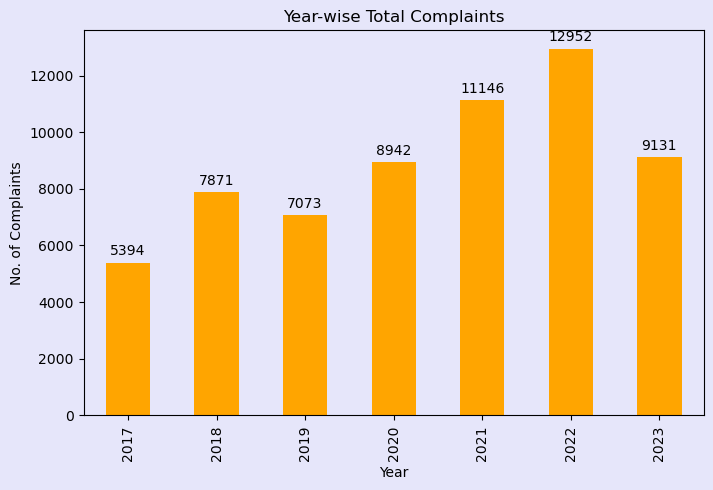

In [20]:
# Checking Year-Wise Total Complaints
df['Date submitted'] = pd.to_datetime(df['Date submitted'])
yearly_trend = df.groupby(df['Date submitted'].dt.year).size()
ax = yearly_trend.plot(kind='bar', figsize=(8,5), title="Year-wise Total Complaints",
xlabel="Year", ylabel="No. of Complaints",color='Orange')
ax.set_facecolor('lavender')
ax.figure.set_facecolor('lavender')
labels = ax.bar_label(ax.containers[0], padding=3, fontsize=10, color='black')

#  CONCLUSION : Customer complaints show an increasing trend over time.

In [21]:
# In the above bar chart the complaints are raising year on year except 2019. But 2023 is not considered for comparision because the
# data is from 01/05/2017 to 28/08/2023. Therefore the No. of complaints may or may not have increased or decreased compared to previous years.

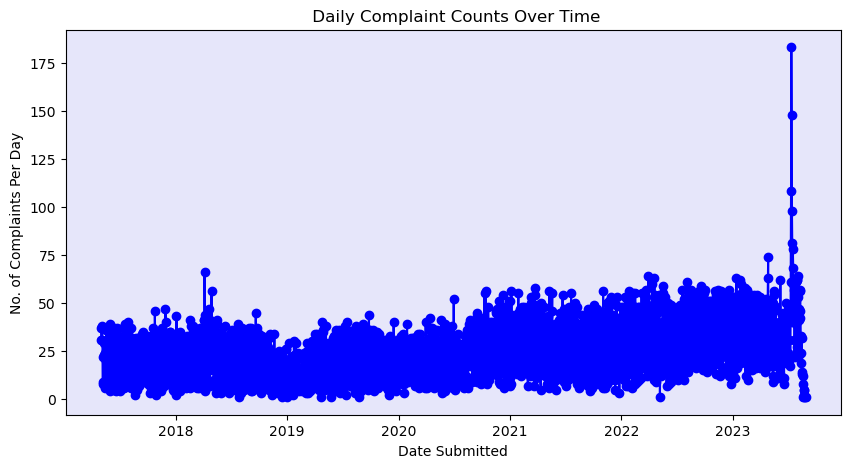

In [22]:
df['Date submitted'] = pd.to_datetime(df['Date submitted'])
trend = df.groupby(df['Date submitted'].dt.date).size()
trend.plot(figsize=(10,5), title=" Daily Complaint Counts Over Time",xlabel="Date Submitted", 
           ylabel="No. of Complaints Per Day", color='blue', marker='o' ).set_facecolor('lavender') 

In [23]:
# In the above chart, observations are :
#  From 2017–2019, daily complaints were generally lower. 
#  From 2020 onward, the number of daily complaints gradually rises. 
#  By 2022–2023, daily complaint counts are consistently higher. But 2023 is not considered for comparision due to inefficient data.
#  Roughly 10 to 50 complaints per day and some days unusually shows high complaint counts and a very large spike near 180 complaints in 2023.
#  After 2021 the complaint numbers become more unpredictable some days are low and some are extremely high. 


In [24]:
import sqlite3
conn = sqlite3.connect('Complaints.db')
df.to_sql('Customer_Complaints_Table', conn, if_exists='replace', index=False)
query = """
SELECT * FROM Customer_Complaints_Table
LIMIT 5
"""
result = pd.read_sql(query, conn)
print(result)

   Complaint ID Submitted via       Date submitted        Date received State  \
0       4848023      Referral  2021-10-24 00:00:00  2021-10-27 00:00:00    NY   
1       3621464           Web  2020-04-24 00:00:00  2020-04-24 00:00:00    FL   
2       5818349           Web  2022-07-27 00:00:00  2022-07-27 00:00:00    CA   
3       7233015      Referral  2023-07-10 00:00:00  2023-07-11 00:00:00    CA   
4       5820224      Referral  2022-07-27 00:00:00  2022-07-28 00:00:00    VA   

                                             Product  \
0                                           Mortgage   
1  Money transfer, virtual currency, or money ser...   
2  Credit reporting, credit repair services, or o...   
3                        Credit card or prepaid card   
4                        Credit card or prepaid card   

                                  Sub-product  \
0                  Conventional home mortgage   
1                   Refund anticipation check   
2                            

In [25]:
# Monthly trend analysis was avoided because the dataset contains partial years (May 2017–Aug 2023), which may produce
# misleading month-level averages. Therefore, quarter-wise aggregation was used for more stable trend interpretation.

In [26]:
query = """
SELECT 
strftime('%Y', `Date submitted`) || '-Q' ||
((CAST(strftime('%m', `Date submitted`) AS INTEGER) - 1) / 3 + 1) AS Complaint_Quarter,
COUNT(`complaint id`) AS Total_Complaints
FROM Customer_Complaints_Table
GROUP BY Complaint_Quarter
ORDER BY Complaint_Quarter;
"""
quarterly_trend = pd.read_sql_query(query, conn)
pd.set_option('display.max_rows', None)
quarterly_trend

#  Complaint volume shows significant quarterly variation/seasonality.

,Complaint_Quarter,Total_Complaints
0,2017-Q2,1445
1,2017-Q3,2002
2,2017-Q4,1947
3,2018-Q1,2064
4,2018-Q2,2262
5,2018-Q3,1982
6,2018-Q4,1563
7,2019-Q1,1282
8,2019-Q2,1868
9,2019-Q3,2058


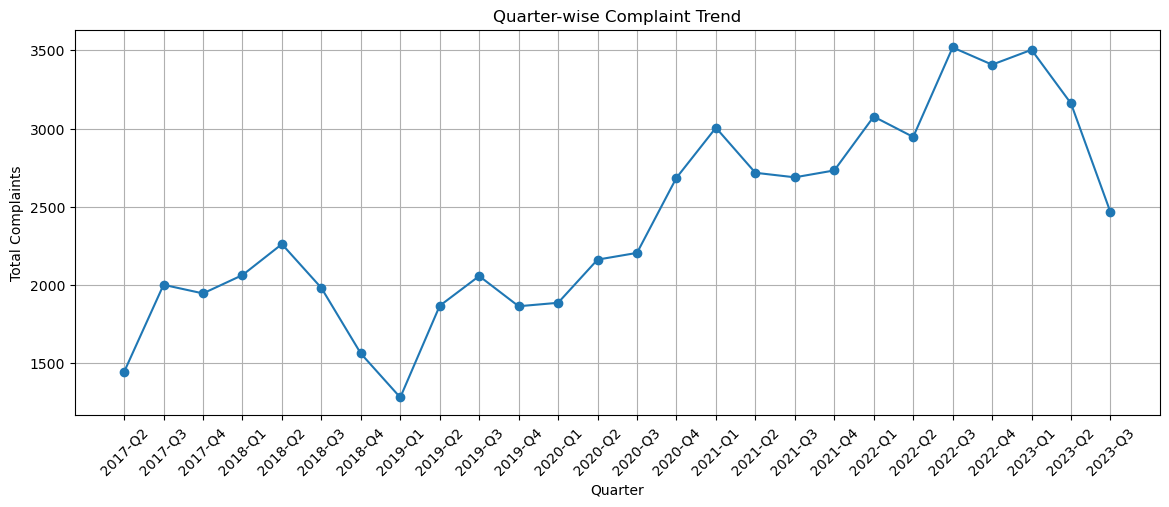

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))
plt.plot(quarterly_trend['Complaint_Quarter'],quarterly_trend['Total_Complaints'],marker='o')
plt.xticks(rotation=45)
plt.title('Quarter-wise Complaint Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Complaints')
plt.grid(True)
plt.show()

In [28]:
# Observations 
# Overall Upward Trend (2017 → 2023)
# Significant Fluctuations Exist
# Strong Growth After 2020
# Peak Complaint Period
# Highest complaint levels occur around: 2022 Q3:2023 Q1
# Decline in 2023 Q3

# CONCLUSION : In the above line chart Quarter-wise complaint analysis reveals a clear upward trend with significant fluctuations across periods, indicating that complaint volume is not
# constant over time. The presence of recurring spikes suggests potential operational or seasonal influences affecting customer experience and 
# complaint generation.


In [29]:
query = """
WITH product_complaints AS (
SELECT 
product,
COUNT(*) AS total_complaints
FROM Customer_Complaints_Table
GROUP BY product),
total_counts AS (
SELECT SUM(total_complaints) AS overall_complaints
FROM product_complaints)
SELECT 
pc.product,
pc.total_complaints,
ROUND( (pc.total_complaints * 100.0 / tc.overall_complaints),2) AS complaint_percentage,
RANK() OVER (ORDER BY pc.total_complaints DESC) AS product_rank
FROM product_complaints pc
CROSS JOIN total_counts tc
ORDER BY pc.total_complaints DESC;
"""
product_analysis = pd.read_sql_query(query, conn)
product_analysis

# Hypothesis 1 :-A single product category or a small group of products accounts for a disproportionately dominant share of complaints.

,product,total_complaints,complaint_percentage,product_rank
0,Checking or savings account,24807,39.69,1
1,Credit card or prepaid card,16197,25.91,2
2,"Credit reporting, credit repair services, or o...",7710,12.33,3
3,Mortgage,6601,10.56,4
4,"Money transfer, virtual currency, or money ser...",3453,5.52,5
5,Debt collection,2736,4.38,6
6,Vehicle loan or lease,633,1.01,7
7,"Payday loan, title loan, or personal loan",333,0.53,8
8,Student loan,39,0.06,9


In [30]:
# Observations :-
# Checking/Savings accounts - 39.69% with 24,807 total complaints
# Credit cards - 25.91% with 16,197 total complaints
# Credit reporting/repair - 12.33% with 7710 total complaints
# Total of top 3: 77.9%  or nearly 80% of all complaints are come from the above mentioned 3 products.

# CONCLUSION : Customer complaints are highly concentrated in basic banking and credit products, with nearly 80% of issues coming from just three 
          #     categories, indicating strong operational inefficiencies in core financial services.

In [31]:
query = """
WITH top_products AS (
SELECT product FROM Customer_Complaints_Table
GROUP BY product
ORDER BY COUNT(*) DESC
LIMIT 3),

issue_analysis AS (
SELECT product, issue,
COUNT(*) AS complaint_count FROM Customer_Complaints_Table
WHERE product IN (SELECT product FROM top_products)
GROUP BY product, issue)
SELECT product, issue, complaint_count,
ROUND(complaint_count * 100.0 / SUM(complaint_count) OVER (PARTITION BY product),2) AS issue_percentage,
RANK() OVER ( PARTITION BY product ORDER BY complaint_count DESC ) AS issue_rank
FROM issue_analysis
ORDER BY product, complaint_count DESC;
"""
issue_analysis = pd.read_sql_query(query, conn)
issue_analysis

# Issue Concentration Within High-Complaint Products
# Hypothesis 2 :- A limited number of issues account for the majority of complaints within high-complaint banking products.

,product,issue,complaint_count,issue_percentage,issue_rank
0,Checking or savings account,Managing an account,15109,60.91,1
1,Checking or savings account,Closing an account,2953,11.90,2
2,Checking or savings account,Opening an account,2725,10.98,3
3,Checking or savings account,Problem with a lender or other company chargin...,2493,10.05,4
4,Checking or savings account,Problem caused by your funds being low,1330,5.36,5
5,Checking or savings account,Incorrect information on your report,124,0.50,6
6,Checking or savings account,Problem with a credit reporting company's inve...,18,0.07,7
7,Checking or savings account,Credit monitoring or identity theft protection...,17,0.07,8
8,Checking or savings account,Problem with fraud alerts or security freezes,17,0.07,8
9,Checking or savings account,Improper use of your report,16,0.06,10


In [32]:
# Observations : Top 4 Issues which covers a >70% of total complaints
#Checking or savings account :-  # Managing an account with total compliants of 15109 with a 60.91% 	 
 		                         # Closing an account with total compliants of 2953 with a 11.90% 	
 	 	                         # Opening an account with total compliants of 2725 with a  10.98%	
                         	 	 # Problem with a lender or other company chargin... with total compliants of 2493 with a 10.05% 	

#Credit card or prepaid card :-  # Problem with a purchase shown on your statement with total compliants of	4415 with a 27.26%	
 	 	                         # Getting a credit card with total compliants of	1867 with a 11.53 %
 	                             # Other features, terms, or problems 	with total compliants of 1633 with a 10.08% 	
 	 	                         # Fees or interest with total compliants of 1422 with a 8.78 %	

# Credit reporting, credit repair services, or o...  Incorrect information on your report 	with total compliants of 4145 with a 	53.76% 	
                                                     # Problem with a credit reporting company's inve...with total compliants of 1641 with a 21.28% 	
                                                      # Improper use of your report 	1517 	with a 19.68% 	
 	                                             #Credit monitoring or identity theft protection... with total compliants of 116 with a 1.50% 	

In [33]:
query = """
WITH sla_analysis AS (
SELECT CASE WHEN `timely response?` = 'Yes' THEN 'Timely'
            WHEN `timely response?` = 'No' THEN 'Delayed'
            ELSE 'Missing' END AS response_status FROM Customer_Complaints_Table)
SELECT response_status,
    COUNT(*) AS complaint_count,ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS percentage_share FROM sla_analysis
GROUP BY response_status
ORDER BY complaint_count DESC;
"""
sla_analysis = pd.read_sql_query(query, conn)
sla_analysis
# Hypothesis 3 : Response outcomes are predominantly timely across customer complaints.

,response_status,complaint_count,percentage_share
0,Timely,58612,93.77
1,Delayed,2403,3.84
2,Missing,1494,2.39


In [34]:
 # A 95% timely response threshold was assumed as the operational benchmark for evaluating complaint handling performance
# the bank is little below from the bench mark and the observations looks like as below : 
     # Timely responsed 58,612 complaints
     # Delayed 	responsed 2,403 complaints
     #  Missing complaints are at 1,494 	
     

In [35]:
query = """
WITH product_sla AS (
SELECT product, COUNT(*) AS total_complaints,
SUM (CASE WHEN `timely response?` = 'Yes' THEN 1
     ELSE 0
     END) AS timely_cases FROM Customer_Complaints_Table
    GROUP BY product)
SELECT product, total_complaints, timely_cases,
ROUND(timely_cases * 100.0 / total_complaints, 2) AS timely_response_rate,
RANK() OVER ( ORDER BY (timely_cases * 100.0 / total_complaints) ASC) AS sla_rank
FROM product_sla
ORDER BY timely_response_rate ASC;
"""
product_sla_analysis = pd.read_sql_query(query, conn)
product_sla_analysis

#Hypothesis 4 : Response performance is consistent across all products.

,product,total_complaints,timely_cases,timely_response_rate,sla_rank
0,"Credit reporting, credit repair services, or o...",7710,7045,91.37,1
1,Debt collection,2736,2514,91.89,2
2,Vehicle loan or lease,633,584,92.26,3
3,Credit card or prepaid card,16197,15096,93.20,4
4,Checking or savings account,24807,23230,93.64,5
5,"Money transfer, virtual currency, or money ser...",3453,3244,93.95,6
6,"Payday loan, title loan, or personal loan",333,321,96.40,7
7,Mortgage,6601,6539,99.06,8
8,Student loan,39,39,100.00,9


In [36]:
# Observations :-
# Product-level SLA analysis indicates that timely response performance remains consistently above 90% across all major banking products. 
# This suggests that operational response efficiency is relatively stable across product categories, despite variations in complaint volume.

In [37]:
query = """
WITH product_sla AS (
SELECT product, COUNT(*) AS total_complaints, 
SUM(CASE WHEN `timely response?` = 'Yes' THEN 1 ELSE 0 END) AS timely_cases,
SUM(CASE WHEN `timely response?` = 'No' THEN 1 ELSE 0 END) AS delayed_cases,
SUM(CASE WHEN `timely response?` = "Missing" THEN 1 ELSE 0 END) AS missing_cases FROM Customer_Complaints_Table
GROUP BY product)
SELECT  product, total_complaints,timely_cases,delayed_cases,missing_cases,
ROUND( timely_cases * 100.0 / total_complaints, 2 ) AS timely_response_rate,
RANK() OVER ( ORDER BY (timely_cases * 100.0 / total_complaints) ASC) AS sla_rank
FROM product_sla
ORDER BY timely_response_rate ASC;
"""
product_sla = pd.read_sql_query(query, conn)
product_sla

,product,total_complaints,timely_cases,delayed_cases,missing_cases,timely_response_rate,sla_rank
0,"Credit reporting, credit repair services, or o...",7710,7045,475,190,91.37,1
1,Debt collection,2736,2514,173,49,91.89,2
2,Vehicle loan or lease,633,584,33,16,92.26,3
3,Credit card or prepaid card,16197,15096,689,412,93.20,4
4,Checking or savings account,24807,23230,867,710,93.64,5
5,"Money transfer, virtual currency, or money ser...",3453,3244,140,69,93.95,6
6,"Payday loan, title loan, or personal loan",333,321,10,2,96.40,7
7,Mortgage,6601,6539,16,46,99.06,8
8,Student loan,39,39,0,0,100.00,9


In [38]:
#The analysis indicates that most major banking products fail to consistently achieve the assumed 95% SLA benchmark for timely complaint responses.
#High-volume products such as Checking/Savings Accounts and Credit Cards exhibit substantial delayed and missing response cases, 
#suggesting operational strain in complaint handling processes.

In [39]:
query = """
WITH state_complaints AS (
SELECT state, COUNT(*) AS total_complaints
FROM Customer_Complaints_Table
GROUP BY state),
overall_total AS (
SELECT 
SUM(total_complaints) AS overall_complaints FROM state_complaints)
SELECT sc.state,sc.total_complaints,
ROUND(sc.total_complaints * 100.0 / ot.overall_complaints, 2) AS complaint_percentage,
RANK() OVER ( ORDER BY sc.total_complaints DESC) AS state_rank FROM state_complaints sc
CROSS JOIN overall_total ot
ORDER BY sc.total_complaints DESC;
"""
state_analysis = pd.read_sql_query(query, conn)
state_analysis
# Specific states contribute a disproportionate share of total complaints.

,state,total_complaints,complaint_percentage,state_rank
0,CA,13708,21.93,1
1,FL,6486,10.38,2
2,TX,4686,7.50,3
3,NY,4441,7.10,4
4,GA,2921,4.67,5
5,NJ,2664,4.26,6
6,IL,2270,3.63,7
7,MA,2140,3.42,8
8,MD,1959,3.13,9
9,VA,1730,2.77,10


In [40]:
#The geographic analysis reveals a strong concentration of complaints within a limited number of states. The top five states account for more than 40%
# of total complaints, while the top ten states contribute over 60%, indicating substantial regional concentration in customer dissatisfaction and
# operational pressure.

In [41]:
query = """
SELECT Round( AVG( julianday(`Date received`) - julianday(`Date submitted`)), 2) AS avg_days_difference
FROM Customer_Complaints_Table;
"""
avg_days_difference = pd.read_sql_query(query, conn)
avg_days_difference
#  The average resolution time between the submission date and received date is 1.22 days.

,avg_days_difference
0,1.22


In [42]:
query = """
SELECT julianday(`Date received`) - julianday(`Date submitted`) AS days_diff
FROM Customer_Complaints_Table
"""
df = pd.read_sql_query(query, conn)

df['days_diff'].describe()

count    62509.000000
mean         1.224880
std          5.649539
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        275.000000
Name: days_diff, dtype: float64

In [43]:
query = """
SELECT *
FROM Customer_Complaints_Table
WHERE julianday(`Date received`) - julianday(`Date submitted`) = 275;
"""
max_delay_complaints = pd.read_sql_query(query, conn)
max_delay_complaints

# Statistical measures (mean, median, standard deviation, and percentiles) indicate a generally normal distribution.
# One extreme outlier of 275 days was observed.
# This may be due to data entry error, administrative/tracking issues, or missed correspondence causing delayed processing.

,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?
0,4481803,Web,2021-06-22 00:00:00,2022-03-24 00:00:00,CA,Debt collection,Credit card debt,Attempts to collect debt not owed,Debt was result of identity theft,Company has responded to the consumer and the ...,Closed with explanation,Yes


In [44]:
query = """
SELECT CASE WHEN julianday(`Date received`) - julianday(`Date submitted`) = 0 THEN '0 days'
WHEN julianday(`Date received`) - julianday(`Date submitted`) <= 7 THEN '1-7 days'
WHEN julianday(`Date received`) - julianday(`Date submitted`) <= 30 THEN '8-30 days'
WHEN julianday(`Date received`) - julianday(`Date submitted`) <= 90 THEN '31-90 days' 
ELSE '90+ days' END AS delay_bucket,
COUNT(*) AS complaint_count FROM Customer_Complaints_Table
GROUP BY delay_bucket;
"""
delay_distribution = pd.read_sql_query(query, conn)
delay_distribution

# 0 days: 49,629 complaints were received on the same day.
# 1–7 days: 10,438 complaints were processed within 7 days, showing most cases are handled quickly.
# Beyond 7 days: Only 2,442 complaints took more than 7 days (8–30 days: 2,007; 31–90 days: 387; 90+ days: 48),
# indicating a small proportion of delayed cases.

,delay_bucket,complaint_count
0,0 days,49629
1,1-7 days,10438
2,31-90 days,387
3,8-30 days,2007
4,90+ days,48


In [45]:
df.to_excel('Bank_Complaints_Cleaned.xlsx', index=False)
print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.
